In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy

# Euclid imports
from cloelite.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelite.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelite.observables.photo import ShearTracer, PositionsTracer
from cloelite.summary_statistics.two_point import AngularTwoPoint
from cloelite.auxiliary.units import SPEED_OF_LIGHT
#from cloelite.observables.two_point import AngularTwoPoint
import euclidlib as el

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

2025-02-19 18:42:19.000926: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1740008539.013019  276004 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1740008539.016351  276004 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


/home/marcobonici/miniconda3/lib/python3.12/site-packages/HMcode2020Emu
Loading linear emulator...


2025-02-19 18:42:20.410658: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error


Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


## Cosmology: Background + Perturbations

Shows how to use CAMB and HMCode2020emu

Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)


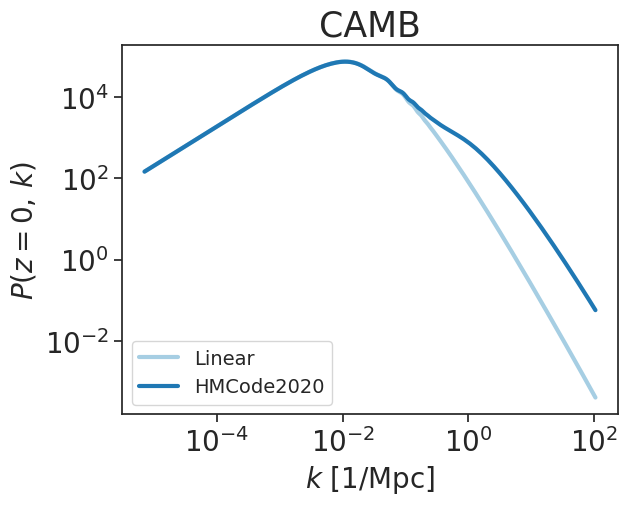

In [2]:
zs = np.linspace(1e-4, 3, 100)

background = CAMBBackground(H0=67.7, 
                            Omega_cdm0=0.26067408193677466, 
                            Omega_b0=0.04902591806322532, 
                            w0=-1, 
                            wa=0, 
                            Omega_k0 = 0.0, 
                            ns = 0.966, 
                            As = 2e-9,
                            gamma_MG = 0.545)
linear_perturbations = CAMBLinearPerturbations(background, zs)
pk_values_linear = linear_perturbations.matter_power_spectrum()

nonlinear_perturbations = CAMBNonLinearPerturbations(background, zs, nonlinear_model = 'mead')
pk_values_nonlinear = nonlinear_perturbations.matter_power_spectrum()

plt.loglog(linear_perturbations.k, pk_values_linear[0, :], label='Linear');
plt.loglog(nonlinear_perturbations.k, pk_values_nonlinear[0, :], label='HMCode2020');
plt.xlabel(r'$k$ [1/Mpc]');
plt.ylabel(r'$P(z=0, \, k)$');
plt.title('CAMB');
plt.legend();

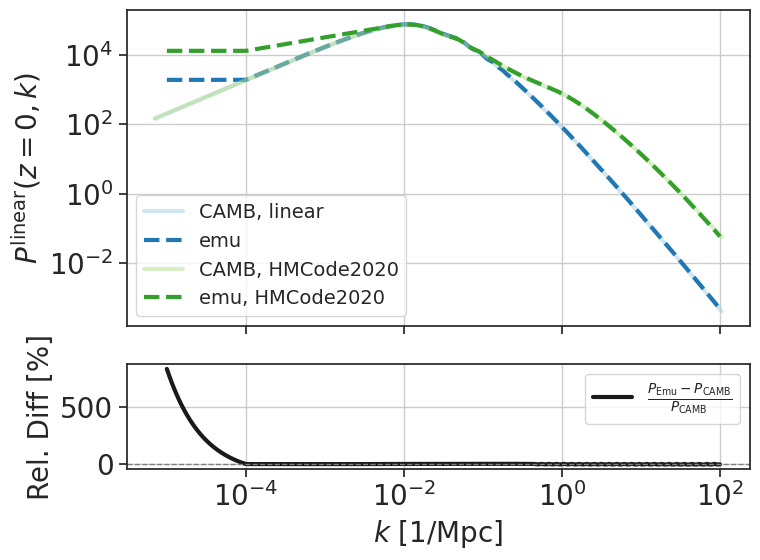

In [3]:
linear_perturbations_emu = HMemuLinearPerturbations(background, zs)
nonlinear_perturbations_emu = HMemuNonLinearPerturbations(background, zs)
ks_for_emu = np.logspace(-5, 2, 1000)
pk_values_linear_emu = linear_perturbations_emu.matter_power_spectrum(linear_perturbations_emu.z, 
                                                                  ks_for_emu)

pk_values_nonlinear_emu = nonlinear_perturbations_emu.matter_power_spectrum(nonlinear_perturbations_emu.z, 
                                                                  ks_for_emu)

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8, 6), gridspec_kw={'height_ratios': [3, 1]})

# First plot: Power spectra
ax[0].loglog(linear_perturbations.k, pk_values_linear[0, :], label='CAMB, linear', alpha=0.5)
ax[0].loglog(ks_for_emu, pk_values_linear_emu[0, :], '--', label='emu')
ax[0].loglog(nonlinear_perturbations.k, pk_values_nonlinear[0, :], label='CAMB, HMCode2020', alpha=0.5)
ax[0].loglog(ks_for_emu, pk_values_nonlinear_emu[0, :], '--', label='emu, HMCode2020')

ax[0].set_ylabel(r'$P^{\rm linear}(z=0, k)$')
ax[0].legend()
ax[0].grid()

# Compute relative difference
interp_camb = interp1d(linear_perturbations.k, pk_values_linear[0, :], kind='linear', bounds_error=False, fill_value="extrapolate")
pk_camb_interp = interp_camb(ks_for_emu)

relative_diff = 100*(pk_values_linear_emu[0, :] - pk_camb_interp) / pk_camb_interp

# Second plot: Relative difference
ax[1].semilogx(ks_for_emu, relative_diff, 'k-', label=r'$\frac{P_{\mathrm{Emu}} - P_{\mathrm{CAMB}}}{P_{\mathrm{CAMB}}}$')
ax[1].axhline(0, color='gray', linestyle='--', linewidth=1)
ax[1].set_xlabel(r'$k$ [1/Mpc]')
ax[1].set_ylabel('Rel. Diff [%]')
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()


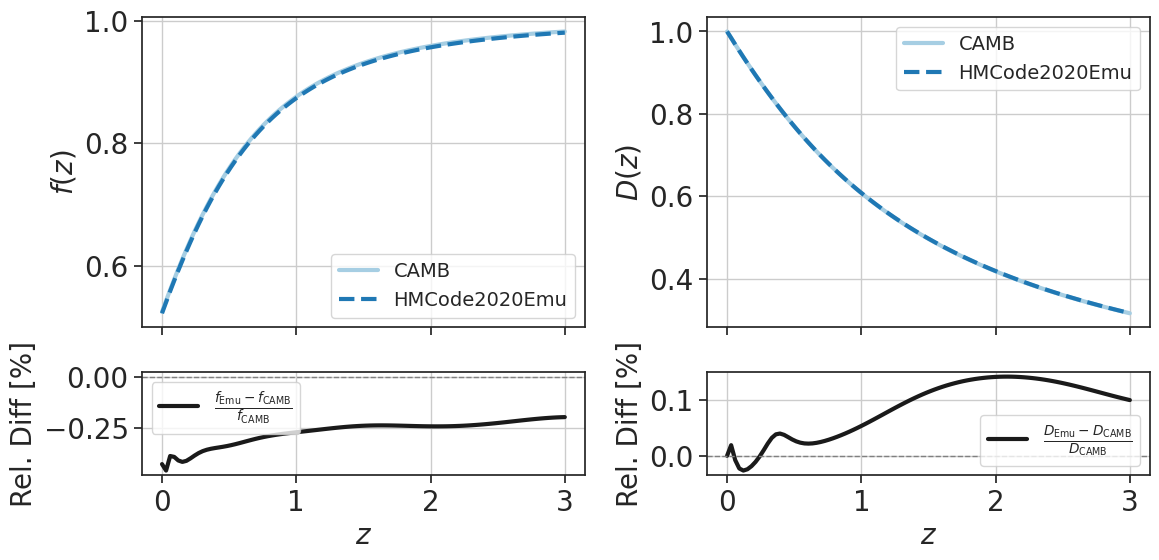

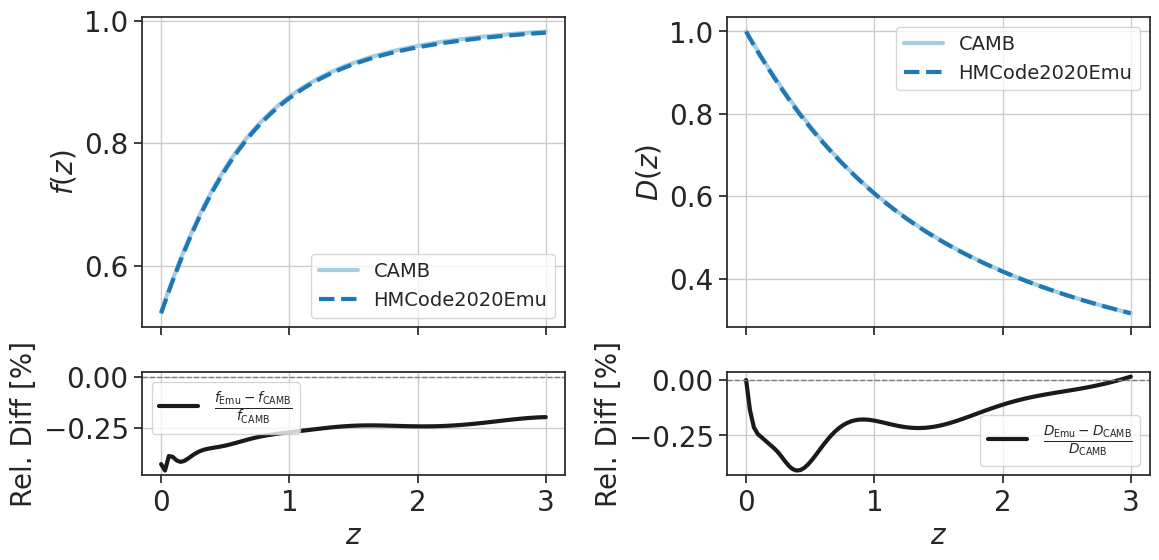

In [4]:
def plot_growth_comparison(camb_perturbations, emu_perturbations):
    """
    Plots the growth rate and growth factor comparisons between CAMB and HMCode2020Emu.
    
    Parameters:
    - camb_perturbations: Object containing growth rate and growth factor from CAMB.
    - emu_perturbations: Object containing growth rate and growth factor from HMCode2020Emu.
    """
    
    fig, ax = plt.subplots(2, 2, sharex=True, figsize=(12, 6), gridspec_kw={'height_ratios': [3, 1]})

    # Growth rate comparison (Left panel)
    ax[0, 0].plot(camb_perturbations.z[::-1], camb_perturbations.growth_rate(), label='CAMB')
    ax[0, 0].plot(emu_perturbations.params_hm_emu['z'], 
                  emu_perturbations.growth_rate(), 
                  '--', 
                  label='HMCode2020Emu')

    ax[0, 0].set_ylabel(r'$f(z)$')
    ax[0, 0].legend()
    ax[0, 0].grid()

    # Compute relative difference for growth rate
    z_emu = emu_perturbations.params_hm_emu['z']
    growth_camb = camb_perturbations.growth_rate()
    growth_emu = emu_perturbations.growth_rate()

    interp_camb = interp1d(camb_perturbations.z[::-1], growth_camb, kind='linear', bounds_error=False, fill_value="extrapolate")
    growth_camb_interp = interp_camb(z_emu)

    relative_diff_rate = 100 * (growth_emu - growth_camb_interp) / growth_camb_interp

    ax[1, 0].plot(z_emu, relative_diff_rate, 'k-', label=r'$\frac{f_{\mathrm{Emu}} - f_{\mathrm{CAMB}}}{f_{\mathrm{CAMB}}}$')
    ax[1, 0].axhline(0, color='gray', linestyle='--', linewidth=1)
    ax[1, 0].set_xlabel(r'$z$')
    ax[1, 0].set_ylabel('Rel. Diff [%]')
    ax[1, 0].legend()
    ax[1, 0].grid()

    # Growth factor comparison (Right panel)
    ax[0, 1].plot(camb_perturbations.z, camb_perturbations.growth_factor()[:, 0], label='CAMB')
    ax[0, 1].plot(z_emu, 
                  emu_perturbations.growth_factor(z_emu, 0)[:, 0], 
                  '--', 
                  label='HMCode2020Emu')

    ax[0, 1].set_ylabel(r'$D(z)$')
    ax[0, 1].legend()
    ax[0, 1].grid()

    # Compute relative difference for growth factor
    growth_camb = camb_perturbations.growth_factor()[:, 0]
    growth_emu = emu_perturbations.growth_factor(z_emu, 0)[:, 0]

    interp_camb = interp1d(camb_perturbations.z, growth_camb, kind='linear', bounds_error=False, fill_value="extrapolate")
    growth_camb_interp = interp_camb(z_emu)

    relative_diff_factor = 100 * (growth_emu - growth_camb_interp) / growth_camb_interp

    ax[1, 1].plot(z_emu, relative_diff_factor, 'k-', label=r'$\frac{D_{\mathrm{Emu}} - D_{\mathrm{CAMB}}}{D_{\mathrm{CAMB}}}$')
    ax[1, 1].axhline(0, color='gray', linestyle='--', linewidth=1)
    ax[1, 1].set_xlabel(r'$z$')
    ax[1, 1].set_ylabel('Rel. Diff [%]')
    ax[1, 1].legend()
    ax[1, 1].grid()

    plt.tight_layout()
    plt.show()

plot_growth_comparison(linear_perturbations, linear_perturbations_emu)
plot_growth_comparison(nonlinear_perturbations, nonlinear_perturbations_emu)


## Reading n(z)

In [5]:
# Read the dndz
z_pos, dndz_pos = el.photo.redshift_distributions('../data/nz.pos.fits')
z_she, dndz_she = el.photo.redshift_distributions('../data/nz.wl.fits')

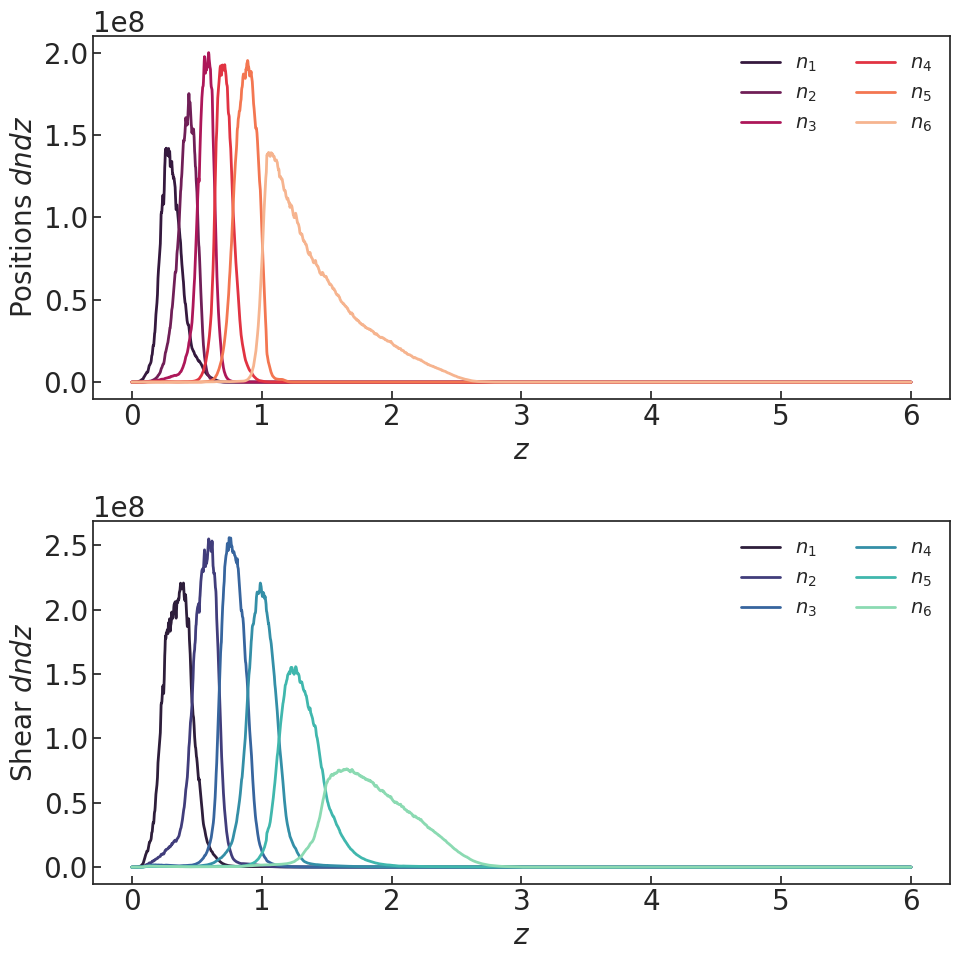

In [6]:
# Plot the dndz
i = 0
j = 0
fig, axs = plt.subplots(2, 1, figsize=(10,10))
for ax in axs.flatten():
    ax.tick_params(axis='both',which='both',direction='in')
for key in dndz_pos.keys():
    axs[0].plot(z_pos, dndz_pos[key], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("rocket", len(dndz_pos.keys()))[i])
    i=i+1
for key in dndz_she.keys():
    axs[1].plot(z_she, dndz_she[key], label = '$n_{{{}}}$'.format(j+1), linewidth=2, color=sns.color_palette("mako", len(dndz_pos.keys()))[j])
    j=j+1
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $dndz$ ')
axs[0].legend(frameon=False, ncol=2)
axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $dndz$ ')
axs[1].legend(frameon=False, ncol=2);
plt.tight_layout()

In [7]:
# Normalise dndz
dndz_pos_norm = deepcopy(dndz_pos)
for key in dndz_pos.keys():
    dndz_pos_norm[key] = dndz_pos[key] / integrate.trapezoid(
                        dndz_pos[key], z_pos)

dndz_she_norm = deepcopy(dndz_she)
for key in dndz_she.keys():
    dndz_she_norm[key] = dndz_she[key] / integrate.trapezoid(
                        dndz_she[key], z_she)


# Resampling the normalized n(z) with 300 values
my_dndz_pos = np.vstack(list(dndz_pos_norm.values()))
myz = np.linspace(1e-4, 3., 100)
my_dndz_pos_norm = np.zeros([len(dndz_pos.keys()), 100])
for i in range(6):
    my_dndz_pos_norm[i,:] = np.interp(myz, z_pos, my_dndz_pos[i,:])

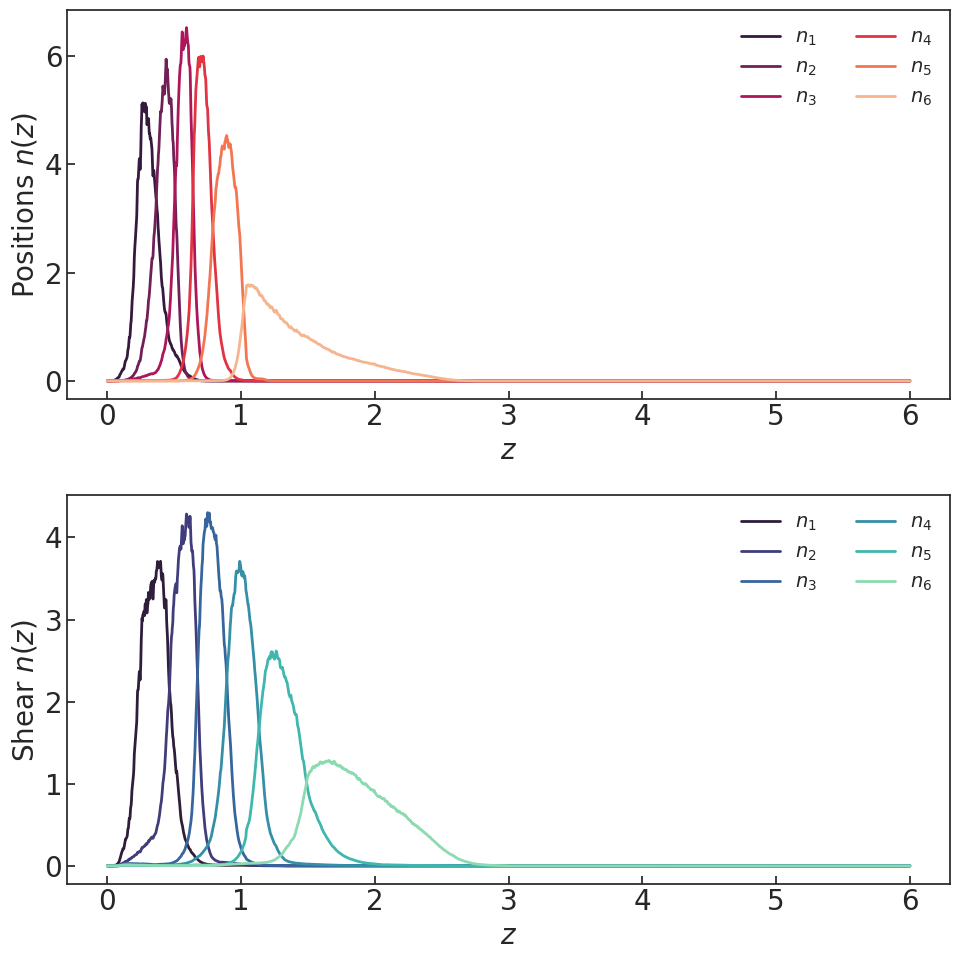

In [8]:
# Plot the dndz
i = 0
j = 0
fig, axs = plt.subplots(2, 1, figsize=(10,10))
for ax in axs.flatten():
    ax.tick_params(axis='both',which='both',direction='in')
for key in dndz_pos.keys():
    axs[0].plot(z_pos, dndz_pos_norm[key], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("rocket", len(dndz_pos.keys()))[i])
    i=i+1
for key in dndz_she.keys():
    axs[1].plot(z_she, dndz_she_norm[key], label = '$n_{{{}}}$'.format(j+1), linewidth=2, color=sns.color_palette("mako", len(dndz_pos.keys()))[j])
    j=j+1
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $n(z)$ ')
axs[0].legend(frameon=False, ncol=2)
axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $n(z)$ ')
axs[1].legend(frameon=False, ncol=2);
plt.tight_layout()

## Observables: tracers & 2-point statistics

In [9]:
# Define the tracers

tracer_pos = PositionsTracer(perturbations=nonlinear_perturbations, 
                             dndz=my_dndz_pos_norm,
                             z = nonlinear_perturbations.z)
twopoint = AngularTwoPoint(tracer_pos, tracer_pos)

In [10]:
nl = 100
ells = np.logspace(1., np.log10(3000), nl)

cells = twopoint.get_Cl(ells, nl, linear_perturbations.k)

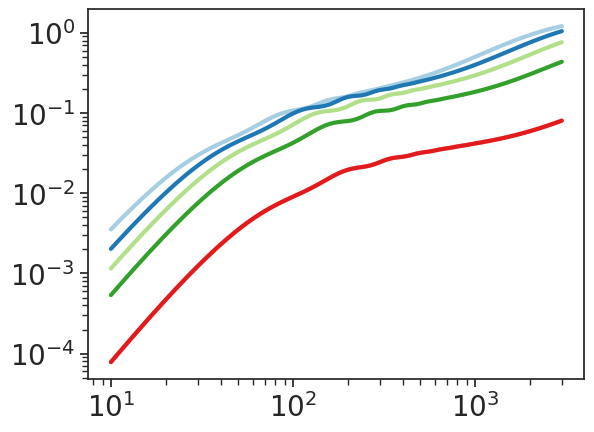

In [11]:
for i in range(1, 7):
    plt.loglog(ells, ells*(2*ells+1)*cells[:, i, i])